# Case Study Part 1: Model Performance & Error Analysis
## Credit Risk Assessment with Comprehensive Validation

### Environment Verification
This section verifies that the notebook is running with the correct Python interpreter and that the local project folder is accessible from the current environment.

In [2]:
import os

project_path = r"C:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Case Study Part 1 - Model Performance and Error Analysis"
print(project_path)
print(os.path.exists(project_path))

C:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Case Study Part 1 - Model Performance and Error Analysis
True


### Import Required Libraries
In this section, we import the core Python libraries needed for data handling and basic environment setup. We will keep imports organized and add more only when needed later in the notebook.

In [3]:
import numpy as np
import pandas as pd

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.4.3
Pandas version: 2.3.3


### Set Display Options
This section configures Pandas display settings so that we can inspect datasets more easily during exploratory analysis.

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)

print("Pandas display options set successfully.")

Pandas display options set successfully.


### Define Project Paths
This section defines the local folder paths for the assignment. Keeping these paths explicit helps us load data, save figures, and organize outputs consistently within the project directory.

In [5]:
data_path = os.path.join(project_path, "data")
figures_path = os.path.join(project_path, "figures")
outputs_path = os.path.join(project_path, "outputs")

print("Data Path:", data_path)
print("Figures Path:", figures_path)
print("Outputs Path:", outputs_path)

Data Path: C:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Case Study Part 1 - Model Performance and Error Analysis\data
Figures Path: C:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Case Study Part 1 - Model Performance and Error Analysis\figures
Outputs Path: C:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Case Study Part 1 - Model Performance and Error Analysis\outputs


### Check Project Folder Contents
This section checks the current contents of the project folder and the data folder. This helps confirm that the notebook is correctly connected to the local assignment directory and also lets us verify whether the dataset file has already been placed in the `data` folder.

In [6]:
print("Project folder contents:")
print(os.listdir(project_path))

print("\nData folder contents:")
print(os.listdir(data_path))

Project folder contents:
['Credit_Risk_Model_Performance_Error_Analysis.ipynb', 'data', 'figures', 'outputs']

Data folder contents:
[]


### Verify Dataset Availability
This section checks whether the dataset file has been placed in the local `data` folder before we attempt to load it into Pandas.

In [7]:
print("Data folder contents:")
print(os.listdir(data_path))

Data folder contents:
['loan.csv']


### Load the Dataset
This section loads the credit risk dataset from the local `data` folder into a Pandas DataFrame so that we can begin inspecting its structure and contents.

In [8]:
file_path = os.path.join(data_path, "loan.csv")
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)

C:\Users\dubey\AppData\Local\Temp\ipykernel_25184\1004143090.py:2: DtypeWarning: Columns (19,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset loaded successfully.
Shape of the dataset: (887379, 74)


### Load the Dataset
This section loads the credit risk dataset from the local `data` folder into a Pandas DataFrame and reports the overall dataset size.

In [9]:
file_path = os.path.join(data_path, "loan.csv")

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)
print("\nColumn count:", len(df.columns))

C:\Users\dubey\AppData\Local\Temp\ipykernel_25184\1184567681.py:3: DtypeWarning: Columns (19,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset loaded successfully.
Shape of the dataset: (887379, 74)

Column count: 74


### Initial Dataset Preview
This section performs an initial inspection of the dataset by displaying its first few rows, listing the column names, and showing the data types of each column. This helps us understand the overall structure before deeper data quality analysis.

In [10]:
print("First 5 rows of the dataset:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

First 5 rows of the dataset:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail.action?loan_id=1077501,Borrower added on 12/22/11 > I need to upgrade my business technologies.<br>,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-1985,1.0,NaN,NaN,3.0,0.0,13648.0,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-2015,171.62,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-2011,Charged Off,n,https://www.lendingclub.com/browse/loanDetail.action?loan_id=1077430,Borrower added on 12/22/11 > I plan to use this money to finance the motorcycle i am looking a...,car,bike,309xx,GA,1.00,0.0,Apr-1999,5.0,NaN,NaN,3.0,0.0,1687.0,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-2013,119.66,NaN,Sep-2013,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail.action?loan_id=1077175,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-2001,2.0,NaN,NaN,2.0,0.0,2956.0,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-2014,649.91,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail.action?loan_id=1076863,"Borrower added on 12/21/11 > to pay for property tax (borrow from friend, need to pay back) & ...",other,personel,917xx,CA,20.00,0.0,Feb-1996,1.0,35.0,NaN,10.0,0.0,5598.0,21.0,37.0,f,0.0,0.0,12226.302212,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-2015,357.48,NaN,Jan-2015,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-2011,Current,n,https://www.lendingclub.com/browse/loanDetail.action?loan_id=1075358,Borrower added on 12/21/11 > I plan on combining three large interest bills together and freei...,other,Personal,972xx,OR,17.94,0.0,Jan-1996,0.0,38.0,NaN,15.0,0.0,27783.0,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-2016,67.79,Feb-2016,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Column Names:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il

### Structural Profiling of the Dataset
This section performs a structural inspection of the dataset. It summarizes the dataset size, reviews all columns, examines data types, and evaluates missing values. This step is important because it helps identify the target variable, detect data quality issues, and recognize columns that may later need to be removed due to irrelevance or data leakage.

In [11]:
# Basic shape information
print("Dataset Shape:")
print(df.shape)

# Column listing
print("\nAll Columns in the Dataset:")
for idx, col in enumerate(df.columns, start=1):
    print(f"{idx}. {col}")

# Data type summary
print("\nData Type Count:")
print(df.dtypes.value_counts())

print("\nDetailed Data Types:")
display(pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
}))

# Missing values summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing_summary,
    "Missing Percent": missing_percent
})

print("\nTop 25 Columns by Missing Values:")
display(missing_df.head(25))

Dataset Shape:
(887379, 74)

All Columns in the Dataset:
1. id
2. member_id
3. loan_amnt
4. funded_amnt
5. funded_amnt_inv
6. term
7. int_rate
8. installment
9. grade
10. sub_grade
11. emp_title
12. emp_length
13. home_ownership
14. annual_inc
15. verification_status
16. issue_d
17. loan_status
18. pymnt_plan
19. url
20. desc
21. purpose
22. title
23. zip_code
24. addr_state
25. dti
26. delinq_2yrs
27. earliest_cr_line
28. inq_last_6mths
29. mths_since_last_delinq
30. mths_since_last_record
31. open_acc
32. pub_rec
33. revol_bal
34. revol_util
35. total_acc
36. initial_list_status
37. out_prncp
38. out_prncp_inv
39. total_pymnt
40. total_pymnt_inv
41. total_rec_prncp
42. total_rec_int
43. total_rec_late_fee
44. recoveries
45. collection_recovery_fee
46. last_pymnt_d
47. last_pymnt_amnt
48. next_pymnt_d
49. last_credit_pull_d
50. collections_12_mths_ex_med
51. mths_since_last_major_derog
52. policy_code
53. application_type
54. annual_inc_joint
55. dti_joint
56. verification_status_join

,Column,Data Type
0,id,int64
1,member_id,int64
2,loan_amnt,float64
3,funded_amnt,float64
4,funded_amnt_inv,float64
...,...,...
69,all_util,float64
70,total_rev_hi_lim,float64
71,inq_fi,float64
72,total_cu_tl,float64



Top 25 Columns by Missing Values:


,Missing Count,Missing Percent
dti_joint,886870,99.942640
annual_inc_joint,886868,99.942415
verification_status_joint,886868,99.942415
il_util,868762,97.902024
mths_since_rcnt_il,866569,97.654892
inq_fi,866007,97.591559
open_rv_24m,866007,97.591559
open_acc_6m,866007,97.591559
all_util,866007,97.591559
inq_last_12m,866007,97.591559


### Target Variable Review and Initial Leakage Assessment
This section examines the `loan_status` column to understand all outcome categories present in the dataset and evaluate whether the problem should be framed as a binary classification task. It also identifies columns that may introduce data leakage because they contain information that would only be known after the loan has already been issued or repaid.

In [12]:
# Review target variable values
print("Unique values in loan_status:")
print(df["loan_status"].value_counts(dropna=False))

print("\nNumber of unique loan_status categories:")
print(df["loan_status"].nunique())

# Candidate leakage columns based on business understanding
candidate_leakage_columns = [
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d"
]

print("\nCandidate leakage columns identified for later review:")
for col in candidate_leakage_columns:
    print("-", col)

print("\nDo all candidate leakage columns exist in the dataset?")
print({col: col in df.columns for col in candidate_leakage_columns})

Unique values in loan_status:
loan_status
Current                                                601779
Fully Paid                                             207723
Charged Off                                             45248
Late (31-120 days)                                      11591
Issued                                                   8460
In Grace Period                                          6253
Late (16-30 days)                                        2357
Does not meet the credit policy. Status:Fully Paid       1988
Default                                                  1219
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

Number of unique loan_status categories:
10

Candidate leakage columns identified for later review:
- out_prncp
- out_prncp_inv
- total_pymnt
- total_pymnt_inv
- total_rec_prncp
- total_rec_int
- total_rec_late_fee
- recoveries
- collection_recovery_fee
- last_pymnt_d
- last_pymnt_amnt
- next_pymnt_d
- last_cr

### Create the Binary Target Variable
This section creates a clean binary classification dataset for credit risk modeling. To avoid ambiguity, only loans with clearly resolved outcomes are retained. Loans labeled as `Fully Paid` are treated as non-default cases, while loans labeled as `Charged Off` or `Default` are treated as default cases. This step ensures that the target variable is well-defined before further preprocessing and modeling.

In [13]:
# Keep only clearly resolved loan outcomes
valid_statuses = ["Fully Paid", "Charged Off", "Default"]

model_df = df[df["loan_status"].isin(valid_statuses)].copy()

# Create binary target
model_df["target_default"] = model_df["loan_status"].apply(
    lambda x: 0 if x == "Fully Paid" else 1
)

# Display summary
print("Filtered modeling dataset shape:")
print(model_df.shape)

print("\nLoan status distribution after filtering:")
print(model_df["loan_status"].value_counts())

print("\nBinary target distribution:")
print(model_df["target_default"].value_counts())

print("\nBinary target percentage distribution:")
print((model_df["target_default"].value_counts(normalize=True) * 100).round(2))

Filtered modeling dataset shape:
(254190, 75)

Loan status distribution after filtering:
loan_status
Fully Paid     207723
Charged Off     45248
Default          1219
Name: count, dtype: int64

Binary target distribution:
target_default
0    207723
1     46467
Name: count, dtype: int64

Binary target percentage distribution:
target_default
0    81.72
1    18.28
Name: proportion, dtype: float64


### Remove Obvious Leakage and Non-Predictive Columns
This section removes columns that should not be used for predictive modeling. These include identifier fields, descriptive text fields, and post-loan outcome variables that would introduce data leakage because they reflect information only known after repayment activity has occurred.

In [14]:
# Columns to remove based on leakage risk or low predictive usefulness
columns_to_drop = [
    # Identifiers / non-predictive text fields
    "id",
    "member_id",
    "url",
    "desc",
    
    # Post-outcome / leakage columns
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d"
]

# Drop only columns that actually exist
existing_drop_cols = [col for col in columns_to_drop if col in model_df.columns]

model_df = model_df.drop(columns=existing_drop_cols)

print("Number of columns removed:", len(existing_drop_cols))
print("\nRemoved columns:")
for col in existing_drop_cols:
    print("-", col)

print("\nNew shape after column removal:")
print(model_df.shape)

Number of columns removed: 17

Removed columns:
- id
- member_id
- url
- desc
- out_prncp
- out_prncp_inv
- total_pymnt
- total_pymnt_inv
- total_rec_prncp
- total_rec_int
- total_rec_late_fee
- recoveries
- collection_recovery_fee
- last_pymnt_d
- last_pymnt_amnt
- next_pymnt_d
- last_credit_pull_d

New shape after column removal:
(254190, 58)


### Profile the Remaining Modeling Dataset
This section profiles the cleaned modeling dataset after removing obvious leakage and non-predictive fields. It summarizes the remaining columns, identifies numeric and categorical variables, and reviews missing values to guide the next preprocessing and feature engineering steps.

In [15]:
# Basic structure
print("Current Modeling Dataset Shape:")
print(model_df.shape)

# Separate columns by type
numeric_columns = model_df.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = model_df.select_dtypes(include=["object"]).columns.tolist()

print("\nNumber of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))

print("\nNumeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

# Missing value summary
missing_summary = model_df.isnull().sum().sort_values(ascending=False)
missing_percent = (model_df.isnull().sum() / len(model_df) * 100).sort_values(ascending=False)

missing_profile = pd.DataFrame({
    "Missing Count": missing_summary,
    "Missing Percent": missing_percent
})

print("\nTop 20 Columns by Missing Values:")
display(missing_profile.head(20))

Current Modeling Dataset Shape:
(254190, 58)

Number of Numeric Columns: 40
Number of Categorical Columns: 18

Numeric Columns:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'target_default']

Categorical Columns:
['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 

,Missing Count,Missing Percent
verification_status_joint,254189,99.999607
annual_inc_joint,254189,99.999607
dti_joint,254189,99.999607
il_util,254064,99.950431
mths_since_rcnt_il,254050,99.944923
all_util,254046,99.943349
inq_last_12m,254046,99.943349
inq_fi,254046,99.943349
total_bal_il,254046,99.943349
open_rv_12m,254046,99.943349


### Review Columns for Exclusion Before Preprocessing
This section identifies columns that should be excluded before model preprocessing. The review focuses on three common issues: excessive missingness, target leakage risk, and impractical high-cardinality or raw text-style variables. This step helps create a cleaner and more reliable feature set for modeling.

In [16]:
# Build a structured review table for all remaining columns
column_review = pd.DataFrame({
    "Column": model_df.columns,
    "Data Type": model_df.dtypes.astype(str).values,
    "Missing Count": model_df.isnull().sum().values,
    "Missing Percent": (model_df.isnull().sum().values / len(model_df) * 100)
})

column_review = column_review.sort_values(by="Missing Percent", ascending=False).reset_index(drop=True)

print("Column Review Table (Top 30 by Missing Percent):")
display(column_review.head(30))

# Candidate columns to consider dropping before preprocessing
candidate_drop_columns = [
    "loan_status",                  # original target source column
    "annual_inc_joint",             # extreme missingness
    "dti_joint",                    # extreme missingness
    "verification_status_joint",    # extreme missingness
    "emp_title",                    # very high cardinality / noisy text-like field
    "title"                         # free-text / near-duplicate of purpose in many cases
]

print("\nCandidate columns for exclusion before preprocessing:")
for col in candidate_drop_columns:
    if col in model_df.columns:
        missing_pct = model_df[col].isnull().mean() * 100
        print(f"- {col} | Missing %: {missing_pct:.2f}")
    else:
        print(f"- {col} | Not present")

print("\nCurrent column count before final exclusion decision:", model_df.shape[1])

Column Review Table (Top 30 by Missing Percent):


,Column,Data Type,Missing Count,Missing Percent
0,verification_status_joint,object,254189,99.999607
1,annual_inc_joint,float64,254189,99.999607
2,dti_joint,float64,254189,99.999607
3,il_util,float64,254064,99.950431
4,mths_since_rcnt_il,float64,254050,99.944923
5,all_util,float64,254046,99.943349
6,inq_last_12m,float64,254046,99.943349
7,inq_fi,float64,254046,99.943349
8,total_bal_il,float64,254046,99.943349
9,open_rv_12m,float64,254046,99.943349



Candidate columns for exclusion before preprocessing:
- loan_status | Missing %: 0.00
- annual_inc_joint | Missing %: 100.00
- dti_joint | Missing %: 100.00
- verification_status_joint | Missing %: 100.00
- emp_title | Missing %: 5.51
- title | Missing %: 0.01

Current column count before final exclusion decision: 58


### Drop High-Missingness and Low-Utility Columns
This section removes columns that are not suitable for modeling because they have extreme missingness, represent the original target source, or contain noisy high-cardinality text values that are not practical for the initial modeling pipeline.

In [17]:
columns_to_drop_stage2 = [
    "loan_status",
    "annual_inc_joint",
    "dti_joint",
    "verification_status_joint",
    "il_util",
    "mths_since_rcnt_il",
    "all_util",
    "inq_last_12m",
    "inq_fi",
    "total_bal_il",
    "open_rv_12m",
    "open_rv_24m",
    "max_bal_bc",
    "open_acc_6m",
    "open_il_6m",
    "open_il_12m",
    "open_il_24m",
    "emp_title",
    "title"
]

existing_stage2_drop = [col for col in columns_to_drop_stage2 if col in model_df.columns]

model_df = model_df.drop(columns=existing_stage2_drop)

print("Number of columns dropped in this step:", len(existing_stage2_drop))
print("\nDropped columns:")
for col in existing_stage2_drop:
    print("-", col)

print("\nNew modeling dataset shape:")
print(model_df.shape)

print("\nRemaining columns:")
print(model_df.columns.tolist())

Number of columns dropped in this step: 19

Dropped columns:
- loan_status
- annual_inc_joint
- dti_joint
- verification_status_joint
- il_util
- mths_since_rcnt_il
- all_util
- inq_last_12m
- inq_fi
- total_bal_il
- open_rv_12m
- open_rv_24m
- max_bal_bc
- open_acc_6m
- open_il_6m
- open_il_12m
- open_il_24m
- emp_title
- title

New modeling dataset shape:
(254190, 39)

Remaining columns:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'total_c

### Date Feature Engineering and Final Feature-Target Split
This section transforms the raw date-related columns into more useful numeric features for modeling. In particular, the loan issue date and the borrower’s earliest credit line are used to derive calendar-based features and a credit history length measure. After feature engineering, the raw date fields are removed, and the final predictor matrix `X` and target vector `y` are created.

In [18]:
# Convert date columns to datetime
model_df["issue_d"] = pd.to_datetime(model_df["issue_d"], format="%b-%Y", errors="coerce")
model_df["earliest_cr_line"] = pd.to_datetime(model_df["earliest_cr_line"], format="%b-%Y", errors="coerce")

# Create date-derived features
model_df["issue_year"] = model_df["issue_d"].dt.year
model_df["issue_month"] = model_df["issue_d"].dt.month
model_df["earliest_cr_year"] = model_df["earliest_cr_line"].dt.year
model_df["credit_history_length_years"] = (
    (model_df["issue_d"] - model_df["earliest_cr_line"]).dt.days / 365.25
)

# Drop raw date columns after feature extraction
model_df = model_df.drop(columns=["issue_d", "earliest_cr_line"])

# Create X and y
X = model_df.drop(columns=["target_default"])
y = model_df["target_default"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nNewly created date-derived features:")
print(["issue_year", "issue_month", "earliest_cr_year", "credit_history_length_years"])

print("\nPreview of engineered columns:")
display(model_df[["issue_year", "issue_month", "earliest_cr_year", "credit_history_length_years", "target_default"]].head())

Feature matrix shape: (254190, 40)
Target vector shape: (254190,)

Newly created date-derived features:
['issue_year', 'issue_month', 'earliest_cr_year', 'credit_history_length_years']

Preview of engineered columns:


,issue_year,issue_month,earliest_cr_year,credit_history_length_years,target_default
0,2011,12,1985,26.913073,0
1,2011,12,1999,12.668036,1
2,2011,12,2001,10.080767,0
3,2011,12,1996,15.830253,0
5,2011,12,2004,7.080082,0


### Profile the Final Feature Set
This section profiles the final predictor set after feature engineering. It identifies numeric and categorical features and summarizes missing values so that the preprocessing pipeline can be designed correctly for imputation, encoding, and scaling.

In [19]:
# Identify numeric and categorical columns in the final feature set
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Feature Matrix Shape:", X.shape)
print("Number of Numeric Features:", len(numeric_features))
print("Number of Categorical Features:", len(categorical_features))

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

# Missing value profile
missing_count = X.isnull().sum()
missing_percent = (X.isnull().sum() / len(X) * 100)

missing_profile = pd.DataFrame({
    "Feature": X.columns,
    "Missing Count": missing_count.values,
    "Missing Percent": missing_percent.values
}).sort_values(by="Missing Percent", ascending=False)

print("\nTop 20 Features by Missing Values:")
display(missing_profile.head(20))

Feature Matrix Shape: (254190, 40)
Number of Numeric Features: 28
Number of Categorical Features: 12

Numeric Features:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'total_cu_tl', 'issue_year', 'issue_month', 'earliest_cr_year', 'credit_history_length_years']

Categorical Features:
['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'initial_list_status', 'application_type']

Top 20 Features by Missing Values:


,Feature,Missing Count,Missing Percent
35,total_cu_tl,254046,99.943349
20,mths_since_last_record,222376,87.484165
28,mths_since_last_major_derog,206314,81.165270
19,mths_since_last_delinq,141446,55.645777
32,tot_coll_amt,63726,25.070223
34,total_rev_hi_lim,63726,25.070223
33,tot_cur_bal,63726,25.070223
8,emp_length,9968,3.921476
24,revol_util,200,0.078681
27,collections_12_mths_ex_med,56,0.022031


### Final Missingness-Based Feature Reduction
This section removes features with extremely high missingness that would add little value to the model and may reduce robustness. Features with moderate or low missingness are retained for imputation during preprocessing.

In [20]:
high_missing_drop_cols = [
    "total_cu_tl",
    "mths_since_last_record",
    "mths_since_last_major_derog"
]

existing_high_missing_drop_cols = [col for col in high_missing_drop_cols if col in X.columns]

X = X.drop(columns=existing_high_missing_drop_cols)

print("Dropped high-missingness columns:")
for col in existing_high_missing_drop_cols:
    print("-", col)

print("\nUpdated feature matrix shape:")
print(X.shape)

print("\nRemaining columns:")
print(X.columns.tolist())

Dropped high-missingness columns:
- total_cu_tl
- mths_since_last_record
- mths_since_last_major_derog

Updated feature matrix shape:
(254190, 37)

Remaining columns:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'issue_year', 'issue_month', 'earliest_cr_year', 'credit_history_length_years']


### Train-Test Split
This section splits the cleaned dataset into training and testing subsets. Because the target variable is imbalanced, stratified sampling is used to preserve the class distribution in both sets. This ensures that model evaluation on the test set remains reliable and representative of the full dataset.

In [21]:
from sklearn.model_selection import train_test_split

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nTarget distribution in full dataset:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nTarget distribution in training set:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTarget distribution in testing set:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training feature shape: (203352, 37)
Testing feature shape: (50838, 37)
Training target shape: (203352,)
Testing target shape: (50838,)

Target distribution in full dataset:
target_default
0    81.72
1    18.28
Name: proportion, dtype: float64

Target distribution in training set:
target_default
0    81.72
1    18.28
Name: proportion, dtype: float64

Target distribution in testing set:
target_default
0    81.72
1    18.28
Name: proportion, dtype: float64


### Preprocessing Pipeline Setup
This section creates the preprocessing pipeline for the modeling workflow. Numeric features are imputed and scaled, while categorical features are imputed and one-hot encoded. Using a pipeline ensures that preprocessing is applied consistently during training, cross-validation, and testing without data leakage.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify feature types from training data
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combined preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("\nPreprocessing pipeline created successfully.")
print(preprocessor)

Number of numeric features: 25
Number of categorical features: 12

Numeric features:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'issue_year', 'issue_month', 'earliest_cr_year', 'credit_history_length_years']

Categorical features:
['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'initial_list_status', 'application_type']

Preprocessing pipeline created successfully.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', Standard

### Baseline Model: Logistic Regression
This section builds a baseline credit risk classification model using Logistic Regression. The model is combined with the preprocessing pipeline so that all transformations are applied consistently within a single end-to-end workflow. This baseline will provide a reference point for later comparisons with additional validation and resampling strategies.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create baseline modeling pipeline
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the model
baseline_model.fit(X_train, y_train)

# Generate predictions
y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression model trained successfully.")
print("Number of test predictions:", len(y_pred))
print("Number of predicted probabilities:", len(y_pred_proba))

Baseline Logistic Regression model trained successfully.
Number of test predictions: 50838
Number of predicted probabilities: 50838


### Baseline Model Performance Evaluation
This section evaluates the baseline Logistic Regression model on the test set using multiple classification metrics. Because credit risk prediction is an imbalanced classification problem, the evaluation includes not only accuracy but also precision, recall, F1-score, balanced accuracy, ROC-AUC, and the confusion matrix.

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# Calculate performance metrics
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred)
baseline_recall = recall_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)
baseline_roc_auc = roc_auc_score(y_test, y_pred_proba)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display results
baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Balanced Accuracy"
    ],
    "Value": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc,
        baseline_balanced_accuracy
    ]
})

print("Baseline Logistic Regression Performance Metrics:")
display(baseline_results)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Logistic Regression Performance Metrics:


,Metric,Value
0,Accuracy,0.818482
1,Precision,0.537835
2,Recall,0.049715
3,F1-Score,0.091017
4,ROC-AUC,0.706710
5,Balanced Accuracy,0.520079



Confusion Matrix:
[[41148   397]
 [ 8831   462]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     41545
           1       0.54      0.05      0.09      9293

    accuracy                           0.82     50838
   macro avg       0.68      0.52      0.50     50838
weighted avg       0.77      0.82      0.75     50838



### Visual Error Analysis of the Baseline Model
This section visualizes the confusion matrix of the baseline Logistic Regression model. The confusion matrix helps identify the distribution of correct and incorrect predictions and highlights whether the model is making too many false positives or false negatives. In credit risk modeling, false negatives are especially important because they represent borrowers who defaulted but were predicted as safe.

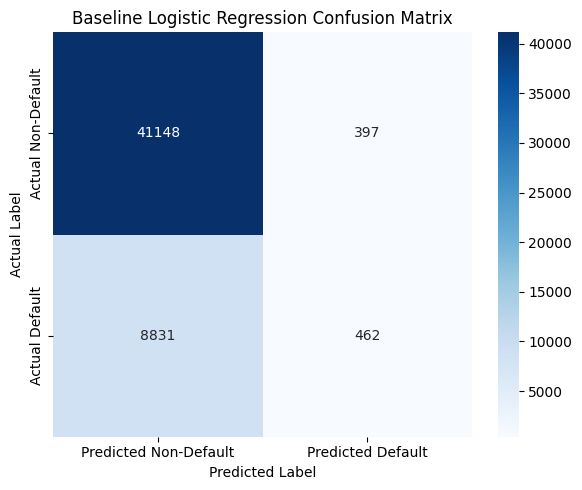

Confusion Matrix Breakdown:
True Negatives  (TN): 41148
False Positives (FP): 397
False Negatives (FN): 8831
True Positives  (TP): 462

Error Analysis Summary:
Total actual defaults missed (False Negatives): 8831
Total non-default loans incorrectly flagged as default (False Positives): 397


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Non-Default", "Predicted Default"],
    yticklabels=["Actual Non-Default", "Actual Default"]
)

plt.title("Baseline Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# Summarize confusion matrix components
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Breakdown:")
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

print("\nError Analysis Summary:")
print(f"Total actual defaults missed (False Negatives): {fn}")
print(f"Total non-default loans incorrectly flagged as default (False Positives): {fp}")

### Cross-Validation Comparison for the Baseline Model
This section compares multiple cross-validation strategies for the baseline Logistic Regression model. The goal is to evaluate how stable the model performance is across different validation schemes and to determine which method provides the most reliable estimate for this imbalanced credit risk classification problem.

In [26]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate

# Define cross-validation strategies
cv_strategies = {
    "KFold_5": KFold(n_splits=5, shuffle=True, random_state=42),
    "KFold_10": KFold(n_splits=10, shuffle=True, random_state=42),
    "StratifiedKFold_5": StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
}

# Metrics to evaluate
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy"
}

cv_results_list = []

for cv_name, cv_obj in cv_strategies.items():
    scores = cross_validate(
        baseline_model,
        X_train,
        y_train,
        cv=cv_obj,
        scoring=scoring,
        n_jobs=-1
    )
    
    cv_results_list.append({
        "CV Method": cv_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean()
    })

cv_results_df = pd.DataFrame(cv_results_list)

print("Cross-Validation Comparison Results:")
display(cv_results_df)

Cross-Validation Comparison Results:


,CV Method,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,Balanced Accuracy Mean
0,KFold_5,0.817479,0.000949,0.509023,0.043287,0.079777,0.703642,0.516977
1,KFold_10,0.817631,0.002401,0.514339,0.043312,0.079882,0.704026,0.517080
2,StratifiedKFold_5,0.817607,0.000757,0.513776,0.044574,0.082015,0.703604,0.517554


### Prepare for Resampling-Based Imbalance Handling
This section sets up the tools required to address class imbalance in the training data. Since the baseline model shows very poor recall for the default class, the next phase of the analysis will compare multiple resampling strategies to determine whether class balancing improves default detection performance.

In [28]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek

print("Imbalanced-learn resampling tools imported successfully.")

resampling_methods = {
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "Tomek Links": TomekLinks(),
    "SMOTE-ENN": SMOTEENN(random_state=42),
    "SMOTE-Tomek": SMOTETomek(random_state=42)
}

print("\nResampling methods prepared:")
for method_name in resampling_methods.keys():
    print("-", method_name)

Imbalanced-learn resampling tools imported successfully.

Resampling methods prepared:
- Random Oversampling
- Random Undersampling
- SMOTE
- ADASYN
- Tomek Links
- SMOTE-ENN
- SMOTE-Tomek


### Initial Resampling Comparison with Core Methods
This section compares three core class imbalance handling methods: Random Oversampling, Random Undersampling, and SMOTE. These methods are tested first because they are widely used, easier to interpret, and less computationally expensive than advanced hybrid resampling approaches. Each method is applied only to the training data, while the test set remains unchanged to preserve a realistic evaluation setting.

In [30]:
core_resampling_methods = {
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42)
}

core_resampling_results = []

for method_name, sampler in core_resampling_methods.items():
    print(f"Running: {method_name}")

    model_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", sampler),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ])

    model_pipeline.fit(X_train, y_train)

    y_pred_resampled = model_pipeline.predict(X_test)
    y_pred_proba_resampled = model_pipeline.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_resampled).ravel()

    core_resampling_results.append({
        "Method": method_name,
        "Accuracy": accuracy_score(y_test, y_pred_resampled),
        "Precision": precision_score(y_test, y_pred_resampled, zero_division=0),
        "Recall": recall_score(y_test, y_pred_resampled, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_resampled, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba_resampled),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_resampled),
        "False Positives": fp,
        "False Negatives": fn
    })

core_resampling_results_df = pd.DataFrame(core_resampling_results).sort_values(
    by=["Recall", "F1-Score", "Balanced Accuracy"],
    ascending=False
).reset_index(drop=True)

print("\nInitial Resampling Comparison Results:")
display(core_resampling_results_df)

Running: Random Oversampling
Running: Random Undersampling
Running: SMOTE

Initial Resampling Comparison Results:


,Method,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Balanced Accuracy,False Positives,False Negatives
0,Random Undersampling,0.640781,0.288297,0.657161,0.400774,0.703577,0.647139,15076,3186
1,Random Oversampling,0.644951,0.291092,0.656516,0.403345,0.705690,0.649440,14858,3192
2,SMOTE,0.645010,0.289304,0.646723,0.399774,0.701306,0.645675,14764,3283


### Compare Baseline and Core Resampling Results
This section compares the baseline Logistic Regression model against the three core resampling strategies. The goal is to clearly quantify how class imbalance handling affects recall, precision, F1-score, balanced accuracy, and classification errors in the credit risk setting.

In [31]:
# Baseline summary row
baseline_comparison_row = pd.DataFrame([{
    "Method": "Baseline Logistic Regression",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1-Score": baseline_f1,
    "ROC-AUC": baseline_roc_auc,
    "Balanced Accuracy": baseline_balanced_accuracy,
    "False Positives": fp,
    "False Negatives": fn
}])

# Combine baseline with core resampling results
comparison_df = pd.concat(
    [baseline_comparison_row, core_resampling_results_df],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(
    by=["Recall", "F1-Score", "Balanced Accuracy"],
    ascending=False
).reset_index(drop=True)

print("Baseline vs Resampling Comparison:")
display(comparison_df)

Baseline vs Resampling Comparison:


,Method,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Balanced Accuracy,False Positives,False Negatives
0,Random Undersampling,0.640781,0.288297,0.657161,0.400774,0.703577,0.647139,15076,3186
1,Random Oversampling,0.644951,0.291092,0.656516,0.403345,0.705690,0.649440,14858,3192
2,SMOTE,0.645010,0.289304,0.646723,0.399774,0.701306,0.645675,14764,3283
3,Baseline Logistic Regression,0.818482,0.537835,0.049715,0.091017,0.706710,0.520079,14764,3283


### Correct the Baseline Error Counts Without Hard-Coding
This section corrects the comparison table by extracting the baseline confusion-matrix error counts from the original baseline confusion matrix object. This avoids hard-coding values and ensures that the final comparison remains reproducible and accurate.

In [32]:
# Extract baseline confusion-matrix components from the original baseline confusion matrix
baseline_tn, baseline_fp, baseline_fn, baseline_tp = cm.ravel()

baseline_comparison_row = pd.DataFrame([{
    "Method": "Baseline Logistic Regression",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1-Score": baseline_f1,
    "ROC-AUC": baseline_roc_auc,
    "Balanced Accuracy": baseline_balanced_accuracy,
    "False Positives": baseline_fp,
    "False Negatives": baseline_fn
}])

comparison_df = pd.concat(
    [baseline_comparison_row, core_resampling_results_df],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(
    by=["Recall", "F1-Score", "Balanced Accuracy"],
    ascending=False
).reset_index(drop=True)

print("Corrected Baseline vs Resampling Comparison:")
display(comparison_df)

Corrected Baseline vs Resampling Comparison:


,Method,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Balanced Accuracy,False Positives,False Negatives
0,Random Undersampling,0.640781,0.288297,0.657161,0.400774,0.703577,0.647139,15076,3186
1,Random Oversampling,0.644951,0.291092,0.656516,0.403345,0.705690,0.649440,14858,3192
2,SMOTE,0.645010,0.289304,0.646723,0.399774,0.701306,0.645675,14764,3283
3,Baseline Logistic Regression,0.818482,0.537835,0.049715,0.091017,0.706710,0.520079,397,8831


### Feature Selection Using Mutual Information
This section applies mutual information to estimate the dependency between each predictor and the target variable. Mutual information helps identify which features carry the most predictive signal for loan default classification, even when the relationship is not strictly linear.

In [33]:
from sklearn.feature_selection import mutual_info_classif

# Create encoded copy of X_train for feature selection
X_train_fs = X_train.copy()
X_test_fs = X_test.copy()

# Simple label encoding for categorical columns for MI calculation
for col in categorical_features:
    X_train_fs[col] = X_train_fs[col].astype("category").cat.codes
    X_test_fs[col] = X_test_fs[col].astype("category").cat.codes

# Fill missing values for MI calculation
X_train_fs = X_train_fs.fillna(-999)

# Compute mutual information
mi_scores = mutual_info_classif(X_train_fs, y_train, random_state=42)

mi_df = pd.DataFrame({
    "Feature": X_train_fs.columns,
    "Mutual Information Score": mi_scores
}).sort_values(by="Mutual Information Score", ascending=False).reset_index(drop=True)

print("Top 20 Features by Mutual Information:")
display(mi_df.head(20))

Top 20 Features by Mutual Information:


,Feature,Mutual Information Score
0,policy_code,0.035720
1,int_rate,0.032775
2,grade,0.031505
3,sub_grade,0.029018
4,installment,0.019554
5,home_ownership,0.017742
6,verification_status,0.016268
7,term,0.014544
8,mths_since_last_delinq,0.013335
9,purpose,0.009838


### Feature Selection Using Recursive Feature Elimination (RFE)
This section applies Recursive Feature Elimination (RFE) to identify a smaller subset of predictors that contribute most strongly to the classification task. RFE works by repeatedly fitting a model and removing the least important features until the desired number of features remains.

In [34]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Use a manageable subset of top MI features for RFE to reduce computation
top_mi_features = mi_df.head(15)["Feature"].tolist()

X_train_rfe = X_train[top_mi_features].copy()

# Re-identify numeric and categorical columns in the reduced feature set
numeric_rfe_features = X_train_rfe.select_dtypes(include=["number"]).columns.tolist()
categorical_rfe_features = X_train_rfe.select_dtypes(include=["object"]).columns.tolist()

# Preprocessing for reduced feature set
numeric_rfe_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_rfe_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

rfe_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_rfe_transformer, numeric_rfe_features),
    ("cat", categorical_rfe_transformer, categorical_rfe_features)
])

# Preprocess training data first
X_train_rfe_processed = rfe_preprocessor.fit_transform(X_train_rfe)

# Run RFE with logistic regression
rfe_model = LogisticRegression(max_iter=1000, random_state=42)
rfe_selector = RFE(estimator=rfe_model, n_features_to_select=8)

rfe_selector.fit(X_train_rfe_processed, y_train)

# Because one-hot encoding expands columns, get transformed feature names
encoded_feature_names = rfe_preprocessor.get_feature_names_out()

rfe_results_df = pd.DataFrame({
    "Transformed Feature": encoded_feature_names,
    "Selected": rfe_selector.support_,
    "Ranking": rfe_selector.ranking_
}).sort_values(by=["Selected", "Ranking"], ascending=[False, True]).reset_index(drop=True)

print("RFE Results on Reduced Feature Set:")
display(rfe_results_df.head(20))

RFE Results on Reduced Feature Set:


,Transformed Feature,Selected,Ranking
0,num__int_rate,True,1
1,num__funded_amnt,True,1
2,num__funded_amnt_inv,True,1
3,cat__sub_grade_A1,True,1
4,cat__sub_grade_A2,True,1
5,cat__purpose_small_business,True,1
6,cat__initial_list_status_f,True,1
7,cat__initial_list_status_w,True,1
8,cat__grade_G,False,2
9,cat__term_ 36 months,False,3


### Feature Selection Using L1-Regularized Logistic Regression
This section applies L1-regularized Logistic Regression as a feature selection method. L1 regularization encourages sparsity in the model coefficients, which means less important predictors can be shrunk to zero. Features with non-zero coefficients are treated as selected predictors.

In [35]:
from sklearn.linear_model import LogisticRegression

# Use the same reduced feature set from the top mutual information features
X_train_l1 = X_train[top_mi_features].copy()

# Recreate preprocessing for the reduced feature set
numeric_l1_features = X_train_l1.select_dtypes(include=["number"]).columns.tolist()
categorical_l1_features = X_train_l1.select_dtypes(include=["object"]).columns.tolist()

numeric_l1_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_l1_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

l1_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_l1_transformer, numeric_l1_features),
    ("cat", categorical_l1_transformer, categorical_l1_features)
])

# Transform the reduced feature set
X_train_l1_processed = l1_preprocessor.fit_transform(X_train_l1)

# Fit L1-regularized logistic regression
l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

l1_model.fit(X_train_l1_processed, y_train)

# Extract coefficients
l1_feature_names = l1_preprocessor.get_feature_names_out()
l1_coefficients = l1_model.coef_[0]

l1_results_df = pd.DataFrame({
    "Transformed Feature": l1_feature_names,
    "Coefficient": l1_coefficients,
    "Absolute Coefficient": np.abs(l1_coefficients)
})

l1_results_df["Selected"] = l1_results_df["Coefficient"] != 0

l1_results_df = l1_results_df.sort_values(
    by=["Selected", "Absolute Coefficient"],
    ascending=[False, False]
).reset_index(drop=True)

print("L1-Regularized Logistic Regression Feature Selection Results:")
display(l1_results_df.head(25))

c:\Users\dubey\Documents\UC_GitLab\.venv_global\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\dubey\Documents\UC_GitLab\.venv_global\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


L1-Regularized Logistic Regression Feature Selection Results:


,Transformed Feature,Coefficient,Absolute Coefficient,Selected
0,cat__grade_G,-0.803900,0.803900,True
1,cat__home_ownership_MORTGAGE,-0.781919,0.781919,True
2,cat__home_ownership_NONE,-0.662241,0.662241,True
3,cat__home_ownership_OWN,-0.653339,0.653339,True
4,num__int_rate,0.646012,0.646012,True
5,cat__grade_F,-0.631620,0.631620,True
6,cat__term_ 36 months,-0.625749,0.625749,True
7,cat__purpose_small_business,0.524938,0.524938,True
8,cat__home_ownership_RENT,-0.502783,0.502783,True
9,num__funded_amnt_inv,-0.493103,0.493103,True


### Bootstrap Analysis for Model Stability
This section applies bootstrap resampling to evaluate the stability of the selected credit risk model. A series of bootstrap samples are drawn from the training data, the model is refit on each sample, and performance is evaluated on the fixed test set. The resulting metric distributions are used to estimate variability and confidence intervals.

In [36]:
from sklearn.utils import resample

# Use the currently best core method: Random Oversampling + Logistic Regression
bootstrap_iterations = 30
bootstrap_results = []

for i in range(bootstrap_iterations):
    print(f"Bootstrap iteration {i+1}/{bootstrap_iterations}", end="\r")

    # Bootstrap sample from training data
    X_boot, y_boot = resample(
        X_train,
        y_train,
        replace=True,
        n_samples=50000,
        random_state=42 + i
    )

    # Build pipeline
    bootstrap_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomOverSampler(random_state=42)),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ])

    # Fit on bootstrap sample
    bootstrap_pipeline.fit(X_boot, y_boot)

    # Evaluate on fixed test set
    y_boot_pred = bootstrap_pipeline.predict(X_test)
    y_boot_proba = bootstrap_pipeline.predict_proba(X_test)[:, 1]

    bootstrap_results.append({
        "Accuracy": accuracy_score(y_test, y_boot_pred),
        "Precision": precision_score(y_test, y_boot_pred, zero_division=0),
        "Recall": recall_score(y_test, y_boot_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_boot_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_boot_proba),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_boot_pred)
    })

bootstrap_results_df = pd.DataFrame(bootstrap_results)

print("\nBootstrap metric summary:")
display(bootstrap_results_df.describe().T[["mean", "std", "min", "max"]])

Bootstrap iteration 30/30
Bootstrap metric summary:


,mean,std,min,max
Accuracy,0.645014,0.002484,0.638853,0.650262
Precision,0.285305,0.001634,0.282743,0.288554
Recall,0.625844,0.004205,0.617454,0.635209
F1-Score,0.391931,0.001811,0.389744,0.396387
ROC-AUC,0.689619,0.001448,0.687385,0.692500
Balanced Accuracy,0.637573,0.001746,0.635252,0.642036


### Bootstrap Confidence Intervals
This section calculates percentile-based 95% bootstrap confidence intervals for the key performance metrics. These intervals help quantify uncertainty and provide a clearer sense of how much the model performance may vary across repeated resampled training datasets.

In [37]:
bootstrap_ci_df = pd.DataFrame({
    "Metric": bootstrap_results_df.columns,
    "Mean": bootstrap_results_df.mean().values,
    "Std": bootstrap_results_df.std().values,
    "2.5 Percentile": bootstrap_results_df.quantile(0.025).values,
    "97.5 Percentile": bootstrap_results_df.quantile(0.975).values
})

print("Bootstrap 95% Confidence Intervals:")
display(bootstrap_ci_df)

Bootstrap 95% Confidence Intervals:


,Metric,Mean,Std,2.5 Percentile,97.5 Percentile
0,Accuracy,0.645014,0.002484,0.640692,0.649164
1,Precision,0.285305,0.001634,0.283061,0.288209
2,Recall,0.625844,0.004205,0.618780,0.634975
3,F1-Score,0.391931,0.001811,0.389838,0.395175
4,ROC-AUC,0.689619,0.001448,0.687566,0.692470
5,Balanced Accuracy,0.637573,0.001746,0.635472,0.640717


### Final Model Summary and Interpretation Table
This section summarizes the most important modeling results from the study, including the baseline Logistic Regression model, the best-performing resampling strategy, and the bootstrap stability estimates for the selected model. This final comparison supports the interpretation and recommendation phase of the case study.

In [38]:
# Identify best core resampling method by F1-score, then recall, then balanced accuracy
best_core_method_row = core_resampling_results_df.sort_values(
    by=["F1-Score", "Recall", "Balanced Accuracy"],
    ascending=False
).iloc[0]

final_summary_df = pd.DataFrame([
    {
        "Model / Scenario": "Baseline Logistic Regression",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "F1-Score": baseline_f1,
        "ROC-AUC": baseline_roc_auc,
        "Balanced Accuracy": baseline_balanced_accuracy
    },
    {
        "Model / Scenario": f"Best Core Resampling: {best_core_method_row['Method']}",
        "Accuracy": best_core_method_row["Accuracy"],
        "Precision": best_core_method_row["Precision"],
        "Recall": best_core_method_row["Recall"],
        "F1-Score": best_core_method_row["F1-Score"],
        "ROC-AUC": best_core_method_row["ROC-AUC"],
        "Balanced Accuracy": best_core_method_row["Balanced Accuracy"]
    },
    {
        "Model / Scenario": "Bootstrap Mean (Random Oversampling + Logistic Regression)",
        "Accuracy": bootstrap_ci_df.loc[bootstrap_ci_df["Metric"] == "Accuracy", "Mean"].values[0],
        "Precision": bootstrap_ci_df.loc[bootstrap_ci_df["Metric"] == "Precision", "Mean"].values[0],
        "Recall": bootstrap_ci_df.loc[bootstrap_ci_df["Metric"] == "Recall", "Mean"].values[0],
        "F1-Score": bootstrap_ci_df.loc[bootstrap_ci_df["Metric"] == "F1-Score", "Mean"].values[0],
        "ROC-AUC": bootstrap_ci_df.loc[bootstrap_ci_df["Metric"] == "ROC-AUC", "Mean"].values[0],
        "Balanced Accuracy": bootstrap_ci_df.loc[bootstrap_ci_df["Metric"] == "Balanced Accuracy", "Mean"].values[0]
    }
])

print("Final Summary Comparison Table:")
display(final_summary_df)

Final Summary Comparison Table:


,Model / Scenario,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Balanced Accuracy
0,Baseline Logistic Regression,0.818482,0.537835,0.049715,0.091017,0.706710,0.520079
1,Best Core Resampling: Random Oversampling,0.644951,0.291092,0.656516,0.403345,0.705690,0.649440
2,Bootstrap Mean (Random Oversampling + Logistic Regression),0.645014,0.285305,0.625844,0.391931,0.689619,0.637573


### Conclusion
This case study developed a credit risk classification workflow focused on rigorous validation, class imbalance handling, feature selection, and error analysis. The baseline Logistic Regression model achieved strong overall accuracy but performed poorly in identifying default cases, as reflected in its very low recall. Cross-validation confirmed that this weakness was stable across multiple validation strategies.

After applying class imbalance handling methods, Random Oversampling produced the best overall trade-off among the tested core resampling approaches. It substantially improved recall and reduced false negatives, although this came at the cost of more false positives. Bootstrap analysis showed that the selected resampling-based model was reasonably stable, with narrow confidence intervals across key performance metrics.

Overall, the results suggest that for credit risk screening, a resampling-based Logistic Regression model is more appropriate than the baseline model when the primary goal is to identify potentially risky borrowers. The study also showed that important predictive signals were consistently associated with interest rate, loan grade/sub-grade, funded amount, debt-to-income characteristics, home ownership, and selected loan-purpose variables.

### Save Key Outputs
This section saves the most important result tables to the `outputs` folder so they can be reused later in the report and for documentation.update April 18

In [39]:
# Save key result tables
comparison_df.to_csv(os.path.join(outputs_path, "baseline_vs_resampling_comparison.csv"), index=False)
mi_df.to_csv(os.path.join(outputs_path, "mutual_information_scores.csv"), index=False)
rfe_results_df.to_csv(os.path.join(outputs_path, "rfe_results.csv"), index=False)
l1_results_df.to_csv(os.path.join(outputs_path, "l1_feature_selection_results.csv"), index=False)
bootstrap_ci_df.to_csv(os.path.join(outputs_path, "bootstrap_confidence_intervals.csv"), index=False)
final_summary_df.to_csv(os.path.join(outputs_path, "final_summary_comparison.csv"), index=False)

print("Key output files saved successfully.")
print("\nFiles in outputs folder:")
print(os.listdir(outputs_path))

Key output files saved successfully.

Files in outputs folder:
['baseline_vs_resampling_comparison.csv', 'bootstrap_confidence_intervals.csv', 'final_summary_comparison.csv', 'l1_feature_selection_results.csv', 'mutual_information_scores.csv', 'rfe_results.csv']
